# 🧠 Mentes Conectadas: os Segredos da Inteligência Artificial
## Encontro 2 — Como uma IA aprende?

Este é o caderno de bordo do segundo encontro, para ser conduzido **ao vivo pelo professor**, projetado para a turma.

**Relembrando o Encontro 1:** aprendemos que uma IA precisa de *dados* e de *features* (características) para observar o mundo. Naquele encontro, **nós mesmos** escrevemos as regras (ex: "se a cor for amarela e o formato for alongado, é uma banana").

**Hoje é diferente:** vamos dar exemplos para a IA e deixar que ela **aprenda sozinha** os padrões — sem escrevermos nenhuma regra.

**Roteiro deste notebook:**
1. 🐾 Como os modelos aprendem → treinando uma IA para reconhecer frutas
2. 💬 Atividade prática → treinando um classificador de frases (elogio vs. reclamação)
3. 🔀 Comparando ferramentas de IA generativa


---
## 1. 🐾 Ensinando uma IA a reconhecer frutas

No Encontro 1, usamos apenas maçã e banana, com regras escritas por nós. Agora vamos:
1. Dar **vários exemplos** de frutas com suas features (dados de **treino**);
2. Deixar um modelo **aprender por conta própria** os padrões que diferenciam cada fruta;
3. Testar esse modelo com **exemplos novos**, que ele nunca viu (dados de **teste**).


In [1]:
# Dados de TREINO: vários exemplos de frutas, já com as features e o rótulo (nome da fruta)
import pandas as pd

frutas_treino = pd.DataFrame({
    "fruta":       ["maçã", "maçã", "maçã", "banana", "banana", "banana", "uva", "uva", "uva"],
    "cor":         ["vermelha", "verde", "vermelha", "amarela", "amarela", "verde", "roxa", "verde", "roxa"],
    "formato":     ["arredondado", "arredondado", "arredondado", "alongado", "alongado", "alongado", "arredondado", "arredondado", "arredondado"],
    "tamanho_cm":  [8, 7, 9, 18, 20, 17, 1.0, 1.0, 1.2],
})

frutas_treino


,fruta,cor,formato,tamanho_cm
0,maçã,vermelha,arredondado,8.0
1,maçã,verde,arredondado,7.0
2,maçã,vermelha,arredondado,9.0
3,banana,amarela,alongado,18.0
4,banana,amarela,alongado,20.0
5,banana,verde,alongado,17.0
6,uva,roxa,arredondado,1.0
7,uva,verde,arredondado,1.0
8,uva,roxa,arredondado,1.2


In [2]:
# Dados de TESTE: exemplos novos, que o modelo NUNCA viu durante o treino
frutas_teste = pd.DataFrame({
    "fruta":       ["maçã", "banana", "uva"],
    "cor":         ["vermelha", "amarela", "roxa"],
    "formato":     ["arredondado", "alongado", "arredondado"],
    "tamanho_cm":  [8.5, 19, 1.1],
})

frutas_teste


,fruta,cor,formato,tamanho_cm
0,maçã,vermelha,arredondado,8.5
1,banana,amarela,alongado,19.0
2,uva,roxa,arredondado,1.1


Um modelo de IA não entende palavras como "vermelha" ou "arredondado" — ele trabalha com números. Por isso, antes de treinar, convertemos essas features em números. Isso ainda faz parte da **engenharia de features** que vimos no Encontro 1!

In [3]:
# Convertendo features em texto para números, para o modelo conseguir usá-las
cor_num = {"vermelha": 0, "verde": 1, "amarela": 2, "roxa": 3}
formato_num = {"arredondado": 0, "alongado": 1}

def preparar_features(df):
    return pd.DataFrame({
        "cor_num": df["cor"].map(cor_num),
        "formato_num": df["formato"].map(formato_num),
        "tamanho_cm": df["tamanho_cm"],
    })

X_treino = preparar_features(frutas_treino)
y_treino = frutas_treino["fruta"]

X_teste = preparar_features(frutas_teste)
y_teste = frutas_teste["fruta"]

X_treino


,cor_num,formato_num,tamanho_cm
0,0,0,8.0
1,1,0,7.0
2,0,0,9.0
3,2,1,18.0
4,2,1,20.0
5,1,1,17.0
6,3,0,1.0
7,1,0,1.0
8,3,0,1.2


In [4]:
# Treinando o modelo: ele observa os exemplos de treino e aprende os padrões sozinho
from sklearn.tree import DecisionTreeClassifier

modelo_frutas = DecisionTreeClassifier(max_depth=3, random_state=0)
modelo_frutas.fit(X_treino, y_treino)

print("Modelo treinado! Ele aprendeu os padrões a partir de", len(X_treino), "exemplos.")


Modelo treinado! Ele aprendeu os padrões a partir de 9 exemplos.


In [5]:
# Testando o modelo com os exemplos de TESTE (que ele nunca viu)
previsoes = modelo_frutas.predict(X_teste)

resultado = frutas_teste[["fruta", "cor", "formato", "tamanho_cm"]].copy()
resultado["previsao_do_modelo"] = previsoes
resultado["acertou?"] = resultado["fruta"] == resultado["previsao_do_modelo"]

resultado


,fruta,cor,formato,tamanho_cm,previsao_do_modelo,acertou?
0,maçã,vermelha,arredondado,8.5,maçã,True
1,banana,amarela,alongado,19.0,banana,True
2,uva,roxa,arredondado,1.1,uva,True


**Discussão com a turma:** o modelo acertou todos os exemplos de teste? Isso mostra que ele conseguiu aprender, a partir dos exemplos, um padrão parecido com o que usaríamos manualmente — só que sem que ninguém precisasse escrever a regra "se a cor for X e o formato for Y..."!

Podemos até visualizar as regras que o próprio modelo criou:

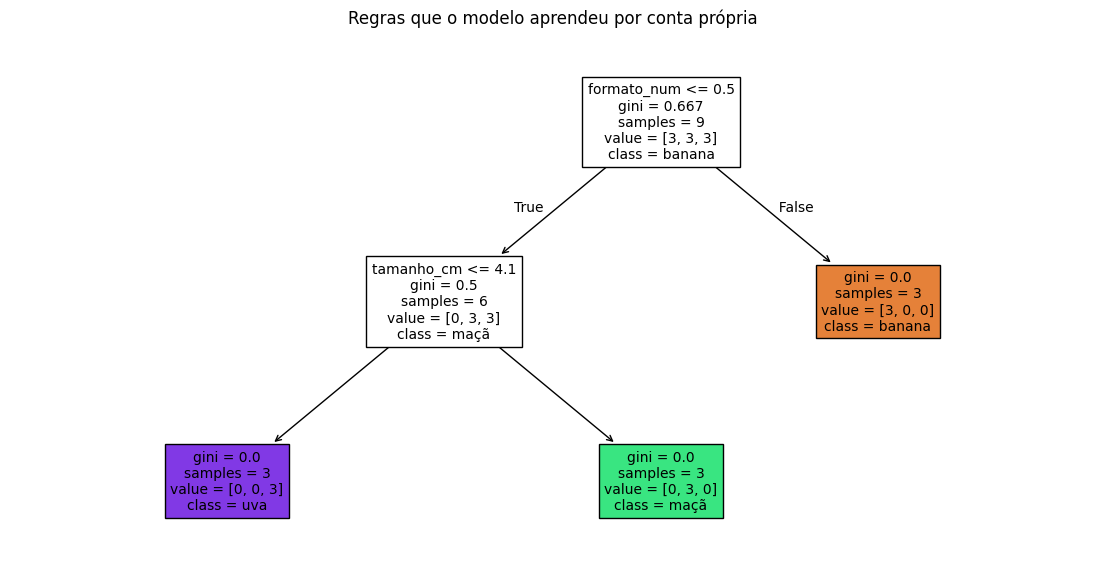

In [6]:
# Visualizando a "árvore de decisão" que o modelo aprendeu sozinho
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(14, 7))
plot_tree(
    modelo_frutas,
    feature_names=["cor_num", "formato_num", "tamanho_cm"],
    class_names=modelo_frutas.classes_,
    filled=True,
    fontsize=10,
)
plt.title("Regras que o modelo aprendeu por conta própria")
plt.show()


**Para testar ao vivo:** peça para um grupo inventar uma fruta nova (com cor, formato e tamanho) e usar a função abaixo para ver o que o modelo prevê.

In [7]:
# ✏️ Teste o modelo com novas combinações de features
def classificar_fruta(cor, formato, tamanho_cm):
    entrada = pd.DataFrame({
        "cor_num": [cor_num.get(cor, -1)],
        "formato_num": [formato_num.get(formato, -1)],
        "tamanho_cm": [tamanho_cm],
    })
    return modelo_frutas.predict(entrada)[0]

# Exemplo: uma fruta verde, arredondada e pequena
classificar_fruta("verde", "arredondado", 1.1)


'uva'

---
## 2. 💬 Atividade prática: treinando um classificador de frases

Agora vamos repetir o mesmo processo — treino, aprendizado e teste — mas com um problema diferente: ensinar uma IA a diferenciar **elogios** de **reclamações**, usando frases sugeridas pela própria turma.


In [8]:
# ✏️ Frases de TREINO: à medida que os grupos sugerem frases, adicione-as aqui com o rótulo correto.
# Este exemplo já vem preenchido para demonstração — na aula, adicione as frases da turma.

frases_treino = [
    ("A aula de hoje foi ótima, aprendi muito!", "elogio"),
    ("Os professores daqui são muito atenciosos.", "elogio"),
    ("Gostei bastante da explicação sobre inteligência artificial.", "elogio"),
    ("A escola está bem organizada esse ano.", "elogio"),
    ("Adorei o projeto de robótica da escola.", "elogio"),
    ("O wi-fi da escola nunca funciona.", "reclamação"),
    ("A sala estava muito quente hoje.", "reclamação"),
    ("Não gostei do lanche de hoje.", "reclamação"),
    ("O quadro estava sujo e difícil de ler.", "reclamação"),
    ("O sinal da escola está sempre atrasado.", "reclamação"),
]

print(f"Total de frases de treino: {len(frases_treino)}")
for frase, rotulo in frases_treino:
    print(f"  [{rotulo}] {frase}")


Total de frases de treino: 10
  [elogio] A aula de hoje foi ótima, aprendi muito!
  [elogio] Os professores daqui são muito atenciosos.
  [elogio] Gostei bastante da explicação sobre inteligência artificial.
  [elogio] A escola está bem organizada esse ano.
  [elogio] Adorei o projeto de robótica da escola.
  [reclamação] O wi-fi da escola nunca funciona.
  [reclamação] A sala estava muito quente hoje.
  [reclamação] Não gostei do lanche de hoje.
  [reclamação] O quadro estava sujo e difícil de ler.
  [reclamação] O sinal da escola está sempre atrasado.


In [9]:
# Treinando o modelo de classificação de texto
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

frases = [f for f, rotulo in frases_treino]
rotulos = [rotulo for f, rotulo in frases_treino]

vetorizador = CountVectorizer()
X_frases = vetorizador.fit_transform(frases)

modelo_frases = MultinomialNB()
modelo_frases.fit(X_frases, rotulos)

print("Modelo de frases treinado!")


Modelo de frases treinado!


In [10]:
# ✏️ Frases de TESTE: cada grupo cria uma frase nova (que o modelo nunca viu) para testar aqui.

frases_teste = [
    "Gostei muito da aula de hoje!",
    "O ônibus da escola está sempre atrasado.",
    "O uniforme da escola é azul e branco.",
]

for frase in frases_teste:
    entrada = vetorizador.transform([frase])
    previsao = modelo_frases.predict(entrada)[0]
    print(f"'{frase}'  →  {previsao.upper()}")


'Gostei muito da aula de hoje!'  →  ELOGIO
'O ônibus da escola está sempre atrasado.'  →  RECLAMAÇÃO
'O uniforme da escola é azul e branco.'  →  RECLAMAÇÃO


**Discussão com a turma:**
- O modelo acertou as frases novas que eram claramente elogios ou reclamações?
- E a última frase — *"O uniforme da escola é azul e branco."* — não é elogio nem reclamação, é apenas uma informação neutra. Mesmo assim, o modelo foi obrigado a "escolher" um dos dois rótulos, porque só ensinamos essas duas opções a ele!
- O que isso nos ensina sobre os limites de uma IA? Ela só é tão boa quanto os exemplos (e as categorias) que recebeu no treino.

> 💡 Isso é exatamente o que acontece com IAs maiores: quanto mais (e melhores) exemplos de treino, e quanto mais bem definidas as categorias, melhor o modelo tende a generalizar para casos novos.


---
## 3. 🔀 Comparando ferramentas de IA generativa

Esta parte é feita **fora deste notebook**: abram, em abas separadas, o Claude, o ChatGPT e o Gemini, e enviem exatamente o mesmo pedido para os três:

> *"Crie uma pequena história (3 frases) sobre um estudante que descobre o mundo da inteligência artificial."*

Depois de comparar as respostas, voltem aqui e registrem, como uma turma, o que observaram.


In [11]:
# ✏️ Preencha esta tabela com o que a turma observou ao comparar as três ferramentas
comparacao = pd.DataFrame({
    "ferramenta": ["Claude", "ChatGPT", "Gemini"],
    "estilo_da_resposta": ["", "", ""],       # ex: "formal", "criativa", "direta"
    "o_que_chamou_atencao": ["", "", ""],     # ex: "resposta mais longa", "usou emojis", "inventou um detalhe estranho"
})

comparacao


,ferramenta,estilo_da_resposta,o_que_chamou_atencao
0,Claude,,
1,ChatGPT,,
2,Gemini,,


---
## ✅ Fechamento do Encontro 2

Hoje aprendemos que:
- Uma IA pode **aprender sozinha** os padrões de um problema, a partir de exemplos de treino — sem que ninguém escreva as regras manualmente.
- Por isso é importante **testar** o modelo com exemplos novos, que ele nunca viu, para saber se ele realmente aprendeu.
- Esse mesmo processo (treino → aprendizado → teste) funciona tanto para reconhecer frutas quanto para classificar frases — e para praticamente qualquer outro problema que uma IA resolve.
- Diferentes ferramentas de IA generativa (Claude, ChatGPT, Gemini) podem responder de formas diferentes ao mesmo pedido.

**No próximo encontro:** vamos discutir onde a IA aparece na nossa vida, os riscos e limites do seu uso, e criar algo autoral usando IA generativa. 🚀
